<a href="https://colab.research.google.com/github/Tulasipriya-yellanki/Machine-Learning---ML/blob/main/PCA%20%20%26%20LDA%20.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## PCA AND LDA

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

#build ml pipelines easily
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import classification_report, accuracy_score

In [2]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data"
df = pd.read_csv(url, names = ['sepal length', 'sepal width', 'petal length', 'petal width','target'])


In [3]:
df.head(5)

,sepal length,sepal width,petal length,petal width,target
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [4]:
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal length  150 non-null    float64
 1   sepal width   150 non-null    float64
 2   petal length  150 non-null    float64
 3   petal width   150 non-null    float64
 4   target        150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [5]:
df['target'].value_counts()

,count
target,
Iris-setosa,50
Iris-versicolor,50
Iris-virginica,50


In [6]:
df.isna().sum()

,0
sepal length,0
sepal width,0
petal length,0
petal width,0
target,0


In [7]:
#PREPARE THE CODE WITH FEATIRES AND MY TARGET

In [8]:
X = df.drop('target',axis=1)
y = df['target']

In [9]:
X.head()

,sepal length,sepal width,petal length,petal width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [10]:
y.head()

,target
0,Iris-setosa
1,Iris-setosa
2,Iris-setosa
3,Iris-setosa
4,Iris-setosa


In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3,
                                                    random_state=42, stratify=y)

In [12]:
X_train.shape[0]
X_test.shape[0]

45

In [13]:
#PCA

# scaler = StandardScaler()
# pca = PCA()

In [14]:
pca_pipeline = Pipeline([
    ('scaler',StandardScaler()),
    ('pca',PCA(n_components=2))
])


# pca_pipeline = Pipeline([
#     ('scaler',StandardScaler()),
#     ('pca',PCA(n_components=2)),
#     ('lr',LogisticRegression(max_iter=1000)),
# ])

In [15]:
X_train_pca = pca_pipeline.fit_transform(X_train)
X_test_pca = pca_pipeline.transform(X_test)

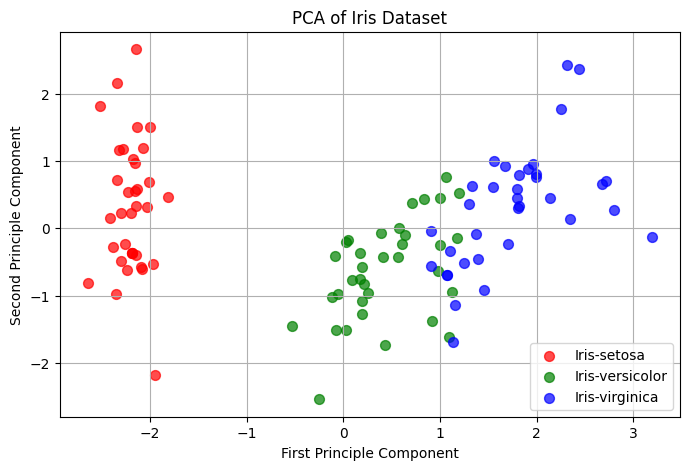

In [16]:
#i want to visulize the data in a simple form
pca_df = pd.DataFrame(data=X_train_pca, columns = ['PC1','PC2'])
pca_df['target'] = y_train.values

plt.figure(figsize=(8,5))
targets = ['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']
colors = ['red', 'green', 'blue']

for target, color in zip(targets, colors):
  indices = pca_df['target'] == target
  plt.scatter(pca_df.loc[indices, 'PC1'], pca_df.loc[indices, 'PC2'],
              c=color, s=50, label = target, alpha=0.7)

plt.title("PCA of Iris Dataset")
plt.xlabel("First Principle Component")
plt.ylabel("Second Principle Component")
plt.grid(True)
plt.legend()

In [17]:
#Explained variance ratio
pca_explained_var = pca_pipeline.named_steps['pca'].explained_variance_ratio_
print(f"\nPCA Explained varinace ratio : {pca_explained_var}")
print(f"Total Variance explained : {sum(pca_explained_var)}")


PCA Explained varinace ratio : [0.72405549 0.23602299]
Total Variance explained : 0.9600784859273446


In [18]:
pca_df.head(5)

,PC1,PC2,target
0,-0.532212,-1.461232,Iris-versicolor
1,1.089732,-1.618493,Iris-versicolor
2,-2.278147,1.176083,Iris-setosa
3,1.995430,0.768438,Iris-virginica
4,0.194109,-0.578720,Iris-versicolor


In [19]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_pca, y_train)
lr_pred = lr.predict(X_test_pca)

In [20]:
#Accuracy and report
print(f"Accuracy : {accuracy_score(y_test, lr_pred):.2f}")

Accuracy : 0.89


In [21]:
print(classification_report(y_test, lr_pred))

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        15
Iris-versicolor       0.78      0.93      0.85        15
 Iris-virginica       0.92      0.73      0.81        15

       accuracy                           0.89        45
      macro avg       0.90      0.89      0.89        45
   weighted avg       0.90      0.89      0.89        45



In [22]:
rf = RandomForestClassifier(n_estimators=250, random_state=42)
rf.fit(X_train_pca, y_train)
rf_pred = rf.predict(X_test_pca)

In [23]:
#Accuracy and report
print(f"Accuracy : {accuracy_score(y_test, rf_pred):.2f}")

Accuracy : 0.93


In [24]:
print(classification_report(y_test, rf_pred))

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        15
Iris-versicolor       0.88      0.93      0.90        15
 Iris-virginica       0.93      0.87      0.90        15

       accuracy                           0.93        45
      macro avg       0.93      0.93      0.93        45
   weighted avg       0.93      0.93      0.93        45



In [25]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train_pca, y_train)
dt_pred = dt.predict(X_test_pca)

In [26]:
# Accuracy and report
print(f"Accuracy : {accuracy_score(y_test, dt_pred):.2f}")

Accuracy : 0.91


In [27]:
print(classification_report(y_test, dt_pred))

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        15
Iris-versicolor       0.82      0.93      0.88        15
 Iris-virginica       0.92      0.80      0.86        15

       accuracy                           0.91        45
      macro avg       0.92      0.91      0.91        45
   weighted avg       0.92      0.91      0.91        45



In [28]:
#LDA

#only resonsible for scaling of the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [29]:
#lda
lda = LinearDiscriminantAnalysis()
X_train_lda = lda.fit_transform(X_train_scaled, y_train)
X_test_lda = lda.transform(X_test_scaled)


#pca
X_train_pca = pca_pipeline.fit_transform(X_train)
X_test_pca = pca_pipeline.transform(X_test)

In [30]:
# classes -> 3 classes : 2d
# class seperability


print(f"\n LDA components : {X_test_lda.shape}")


 LDA components : (45, 2)


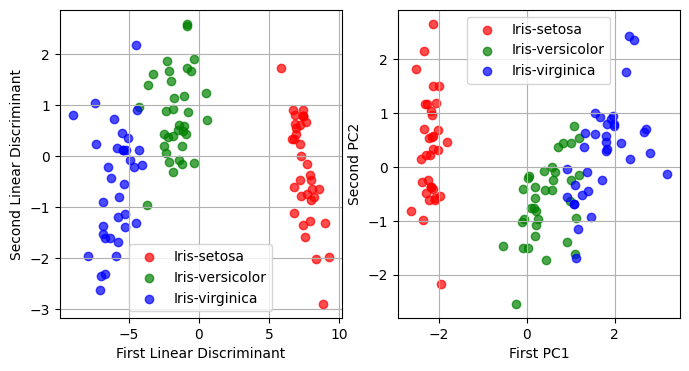

In [31]:
fig, (ax1,ax2) = plt.subplots(1,2,figsize=(8,4))

for target, color in zip(targets, colors):
  indices = y_train == target
  ax1.scatter(X_train_lda[indices,0], X_train_lda[indices,1],
              c=color, label = target, alpha = 0.7)
ax1.set_xlabel("First Linear Discriminant")
ax1.set_ylabel("Second Linear Discriminant")
ax1.grid(True)
ax1.legend()


for target, color in zip(targets, colors):
  indices = y_train == target
  ax2.scatter(X_train_pca[indices,0], X_train_pca[indices,1],
              c=color, label = target, alpha = 0.7)
ax2.set_xlabel("First PC1")
ax2.set_ylabel("Second PC2")
ax2.grid(True)
ax2.legend()

In [32]:
#cross validation

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

#cross validarion with pca
pca_lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=2)),
    ('lr',LogisticRegression(max_iter=1000, random_state=42))
])

cv_scores = cross_val_score(pca_lr_pipeline, X_train, y_train, cv=skf)

In [33]:
print(f"PCA + LOG REG With CV : {cv_scores}")

PCA + LOG REG With CV : [0.76190476 0.9047619  0.85714286 0.95238095 1.        ]


In [34]:
orig_lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('lr',LogisticRegression(max_iter=1000, random_state=42))
])

cv_scores_orig = cross_val_score(orig_lr_pipeline, X_train, y_train, cv=skf)

In [35]:
print(f"LOG REG With CV : {cv_scores_orig}")

LOG REG With CV : [0.95238095 1.         1.         1.         0.95238095]
